Parsing JSONL: 100%|█████████████████████████| 224533/224533 [00:26<00:00, 8514.14rec/s]


Loaded 224533 embeddings in 36.4s

=== Project 1/4: linux ===
  Source: (170682, 768) (vuln=4852) | Target: (53851, 768) (vuln=1152)

  --- Method 1/4: SMOTE ---
    Figures already exist -- skipping.

  --- Method 2/4: ADASYN ---
    Figures already exist -- skipping.

  --- Method 3/4: SVMSMOTE ---
    Figures already exist -- skipping.

  --- Method 4/4: GAN ---
    Figures already exist -- skipping.

=== Project 2/4: poppler ===
  Source: (222735, 768) (vuln=5971) | Target: (1798, 768) (vuln=33)

  --- Method 1/4: SMOTE ---
    Figures already exist -- skipping.

  --- Method 2/4: ADASYN ---
    Figures already exist -- skipping.

  --- Method 3/4: SVMSMOTE ---
    Figures already exist -- skipping.

  --- Method 4/4: GAN ---
    Figures already exist -- skipping.

=== Project 3/4: ImageMagick ===
  Source: (219688, 768) (vuln=5645) | Target: (4845, 768) (vuln=359)

  --- Method 1/4: SMOTE ---
    Figures already exist -- skipping.

  --- Method 2/4: ADASYN ---
    Figures already 

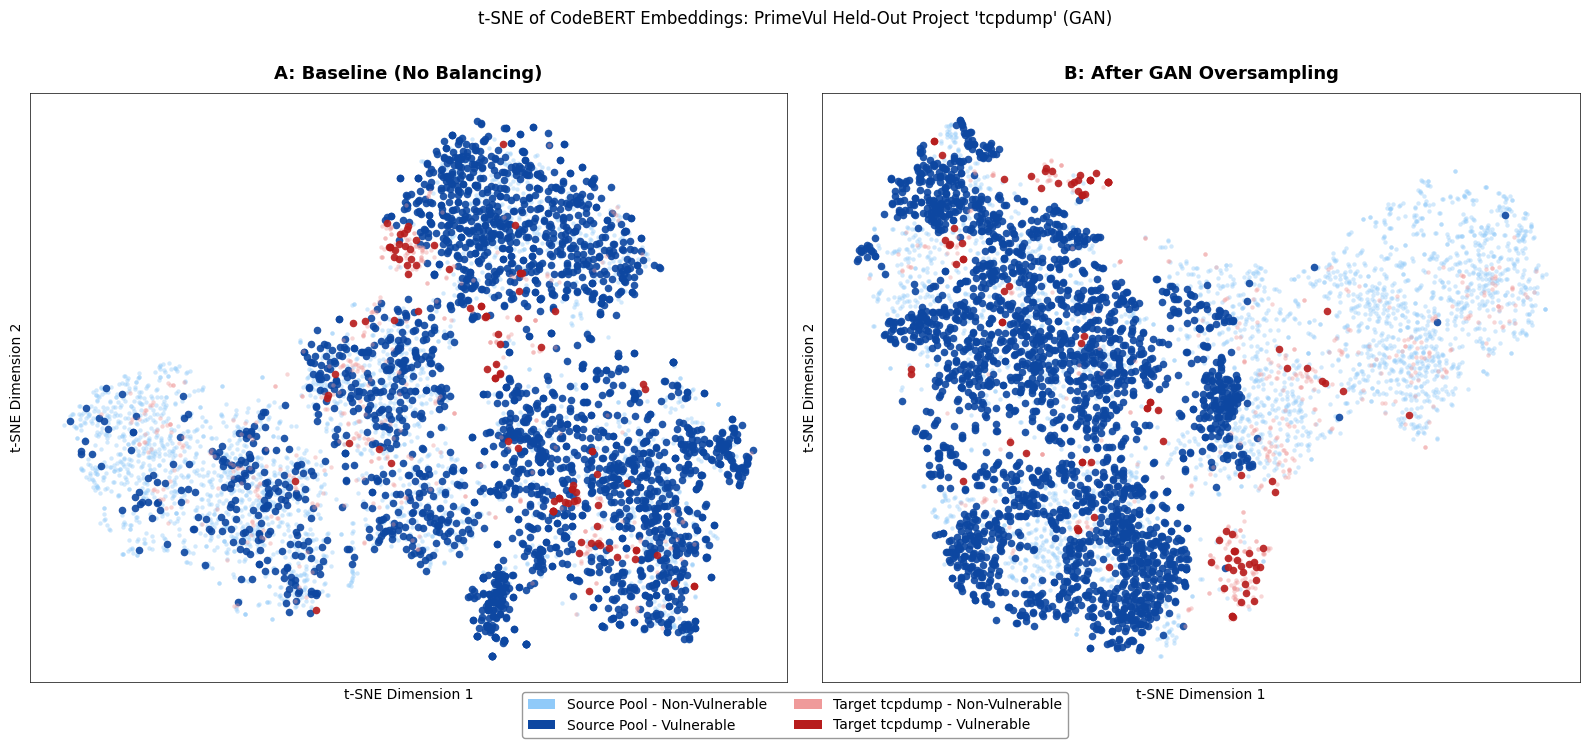


ALL PROJECTS AND METHODS PROCESSED.
Figures saved in: results/tsne_primevul


In [1]:
"""
t-SNE Domain Shift Visualisation for PrimeVul (Representative Projects)
--------------------------------------------------------------------------
Generates one Baseline vs Method panel figure per project per method
"""

import os
import gc
import time
import warnings
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE, ADASYN, SVMSMOTE

warnings.filterwarnings("ignore")


COMBINED_FILE = "../../../../../embedding/primevul/codebert/primevul_embedded.jsonl"
EMB_KEY       = "emb"
CACHE_DIR     = "results/oversample_cache"
OUTPUT_DIR    = "results/tsne_primevul"
SEED          = 42

REPRESENTATIVE_PROJECTS = ["linux", "poppler", "ImageMagick", "tcpdump"]
METHODS = ["SMOTE", "ADASYN", "SVMSMOTE", "GAN"]

TSNE_MAX_POINTS    = 5000
TSNE_PERPLEXITY    = 30
TSNE_LEARNING_RATE = 200
TSNE_MAX_ITER       = 1000

GAN_LATENT_DIM  = 100
GAN_EPOCHS      = 1500
GAN_BATCH_SIZE  = 64
GAN_LOG_EVERY   = 500

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"

COLORS = {
    (0, 0): "#90CAF9", (0, 1): "#0D47A1",
    (1, 0): "#EF9A9A", (1, 1): "#B71C1C",
}
ALPHA = {0: 0.40, 1: 0.90}
SIZE  = {0: 10, 1: 30}


class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim)
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


def load_all_embeddings():
    t0 = time.time()
    X, y, projects = [], [], []
    with open(COMBINED_FILE, "r") as f:
        lines = f.readlines()
    for line in tqdm(lines, desc="Parsing JSONL", unit="rec"):
        line = line.strip()
        if not line:
            continue
        rec = json_loads_safe(line)
        X.append(rec[EMB_KEY])
        y.append(rec["target"])
        projects.append(rec["project"])
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int32)
    projects = np.array(projects, dtype=object)
    print(f"Loaded {X.shape[0]} embeddings in {time.time() - t0:.1f}s")
    return X, y, projects


def json_loads_safe(line):
    import json
    return json.loads(line)


def build_project_split(X_all, y_all, proj_all, held_out_project):
    actual_name = held_out_project.split("_s")[0] if held_out_project.startswith("radare2") else held_out_project

    target_mask = proj_all == actual_name
    source_mask = ~target_mask

    if target_mask.sum() == 0:
        raise ValueError(f"No embeddings found for project '{actual_name}'.")

    source_emb = X_all[source_mask]
    source_lbl = y_all[source_mask]
    target_emb = X_all[target_mask]
    target_lbl = y_all[target_mask]

    return source_emb, source_lbl, target_emb, target_lbl


def generate_gan_embeddings(source_emb, source_lbl):
    input_dim = source_emb.shape[1]
    minority_emb = source_emb[source_lbl == 1].astype(np.float32)
    n_to_generate = int(np.sum(source_lbl == 0)) - int(np.sum(source_lbl == 1))

    print(f"    Minority samples: {minority_emb.shape[0]} | Target to generate: {n_to_generate}")

    G = Generator(GAN_LATENT_DIM, input_dim).to(DEVICE)
    D = Discriminator(input_dim).to(DEVICE)
    opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    minority_tensor = torch.tensor(minority_emb).to(DEVICE)
    dataset = TensorDataset(minority_tensor)
    loader = DataLoader(dataset, batch_size=GAN_BATCH_SIZE, shuffle=True)

    t0 = time.time()
    epoch_bar = tqdm(range(GAN_EPOCHS), desc="    GAN training", leave=False)
    for epoch in epoch_bar:
        for (real_batch,) in loader:
            bs = real_batch.size(0)

            z = torch.randn(bs, GAN_LATENT_DIM).to(DEVICE)
            fake = G(z).detach()
            loss_D = criterion(D(real_batch), torch.ones(bs, 1).to(DEVICE)) + \
                     criterion(D(fake), torch.zeros(bs, 1).to(DEVICE))
            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            z = torch.randn(bs, GAN_LATENT_DIM).to(DEVICE)
            loss_G = criterion(D(G(z)), torch.ones(bs, 1).to(DEVICE))
            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

        if (epoch + 1) % GAN_LOG_EVERY == 0:
            epoch_bar.set_postfix({"D_loss": f"{loss_D.item():.4f}", "G_loss": f"{loss_G.item():.4f}"})

    print(f"    GAN training complete in {time.time() - t0:.1f}s")

    G.eval()
    with torch.no_grad():
        z = torch.randn(n_to_generate, GAN_LATENT_DIM).to(DEVICE)
        synthetic = G(z).cpu().numpy()

    resampled_emb = np.vstack([source_emb, synthetic]).astype(np.float32)
    resampled_lbl = np.concatenate([source_lbl, np.ones(n_to_generate, dtype=int)])

    del G, D, opt_G, opt_D, minority_tensor, dataset, loader
    gc.collect()
    if DEVICE == "mps":
        torch.mps.empty_cache()
    elif DEVICE == "cuda":
        torch.cuda.empty_cache()

    return resampled_emb, resampled_lbl


def load_source_for_method(project, method, source_emb_scaled, source_lbl):
    cache_path = os.path.join(CACHE_DIR, f"{project}_{method}.npy")
    if os.path.exists(cache_path):
        print(f"  Loading cached {method} embeddings for {project} from disk...")
        resampled_emb = np.load(cache_path).astype(np.float32)
        n_new = resampled_emb.shape[0] - source_emb_scaled.shape[0]
        resampled_lbl = np.concatenate([source_lbl, np.ones(n_new, dtype=int)]) if n_new > 0 else source_lbl
        return resampled_emb, resampled_lbl

    print(f"  No cache found for {project}/{method} -- generating now...")
    t0 = time.time()

    if method == "SMOTE":
        sampler = SMOTE(random_state=SEED)
        resampled_emb, resampled_lbl = sampler.fit_resample(source_emb_scaled, source_lbl)
    elif method == "ADASYN":
        sampler = ADASYN(random_state=SEED)
        resampled_emb, resampled_lbl = sampler.fit_resample(source_emb_scaled, source_lbl)
    elif method == "SVMSMOTE":
        sampler = SVMSMOTE(random_state=SEED)
        resampled_emb, resampled_lbl = sampler.fit_resample(source_emb_scaled, source_lbl)
    elif method == "GAN":
        resampled_emb, resampled_lbl = generate_gan_embeddings(source_emb_scaled, source_lbl)
    else:
        raise ValueError(f"Unknown method: {method}")

    resampled_emb = resampled_emb.astype(np.float32)
    np.save(cache_path, resampled_emb)
    print(f"  Generated and cached {project}/{method} in {time.time() - t0:.1f}s. "
          f"Shape: {source_emb_scaled.shape} -> {resampled_emb.shape}")

    return resampled_emb, resampled_lbl


def stratified_subsample(emb, lbl, max_points, seed=SEED):
    rng = np.random.RandomState(seed)
    idx_pos = np.where(lbl == 1)[0]
    idx_neg = np.where(lbl == 0)[0]

    n_pos_keep = min(len(idx_pos), max_points // 2)
    if len(idx_pos) > n_pos_keep:
        idx_pos = rng.choice(idx_pos, n_pos_keep, replace=False)

    remaining = max_points - len(idx_pos)
    n_neg_keep = min(len(idx_neg), remaining)
    if len(idx_neg) > n_neg_keep:
        idx_neg = rng.choice(idx_neg, n_neg_keep, replace=False)

    idx = np.concatenate([idx_pos, idx_neg])
    return emb[idx], lbl[idx]


def run_tsne(embeddings, label):
    print(f"  Running t-SNE on {len(embeddings)} points ({label})...")
    tsne = TSNE(
        n_components=2,
        perplexity=TSNE_PERPLEXITY,
        learning_rate=TSNE_LEARNING_RATE,
        max_iter=TSNE_MAX_ITER,
        random_state=SEED,
        n_jobs=-1,
        verbose=0,
    )
    return tsne.fit_transform(embeddings)


def plot_panels(coords_a, dom_a, lbl_a, coords_b, dom_b, lbl_b, project, method,
                 save_path_pdf, save_path_png):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.subplots_adjust(wspace=0.15)

    panel_data = [
        (axes[0], coords_a, dom_a, lbl_a, "A: Baseline (No Balancing)"),
        (axes[1], coords_b, dom_b, lbl_b, f"B: After {method} Oversampling"),
    ]

    for ax, coords, domains, labels, title in panel_data:
        for domain in [0, 1]:
            for cls in [0, 1]:
                mask = (domains == domain) & (labels == cls)
                if mask.sum() == 0:
                    continue
                ax.scatter(
                    coords[mask, 0], coords[mask, 1],
                    c=COLORS[(domain, cls)],
                    s=SIZE[cls],
                    alpha=ALPHA[cls],
                    linewidths=0,
                    rasterized=True,
                )
        ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
        ax.set_xlabel("t-SNE Dimension 1", fontsize=10)
        ax.set_ylabel("t-SNE Dimension 2", fontsize=10)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

    legend_elements = [
        mpatches.Patch(facecolor="#90CAF9", label="Source Pool - Non-Vulnerable"),
        mpatches.Patch(facecolor="#0D47A1", label="Source Pool - Vulnerable"),
        mpatches.Patch(facecolor="#EF9A9A", label=f"Target {project} - Non-Vulnerable"),
        mpatches.Patch(facecolor="#B71C1C", label=f"Target {project} - Vulnerable"),
    ]
    fig.legend(
        handles=legend_elements, loc="lower center", ncol=2,
        fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.04), edgecolor="grey"
    )

    fig.suptitle(
        f"t-SNE of CodeBERT Embeddings: PrimeVul Held-Out Project '{project}' ({method})",
        fontsize=12, y=1.01
    )

    plt.tight_layout()
    plt.savefig(save_path_pdf, bbox_inches="tight", dpi=300)
    plt.savefig(save_path_png, bbox_inches="tight", dpi=300)
    print(f"  Figure saved: {save_path_pdf}")
    print(f"  Figure saved: {save_path_png}")
    plt.show()


def main():
    X_all, y_all, proj_all = load_all_embeddings()

    n_projects = len(REPRESENTATIVE_PROJECTS)
    for p_idx, project in enumerate(REPRESENTATIVE_PROJECTS, start=1):
        print(f"\n=== Project {p_idx}/{n_projects}: {project} ===")

        project_out_dir = os.path.join(OUTPUT_DIR, project)
        os.makedirs(project_out_dir, exist_ok=True)

        source_emb, source_lbl, target_emb, target_lbl = build_project_split(
            X_all, y_all, proj_all, project
        )

        scaler = StandardScaler()
        source_emb_scaled = scaler.fit_transform(source_emb).astype(np.float32)
        target_emb_scaled = scaler.transform(target_emb).astype(np.float32)

        print(f"  Source: {source_emb_scaled.shape} (vuln={int(source_lbl.sum())}) "
              f"| Target: {target_emb_scaled.shape} (vuln={int(target_lbl.sum())})")

        source_sample, source_sample_lbl = stratified_subsample(
            source_emb_scaled, source_lbl, TSNE_MAX_POINTS
        )
        target_sample, target_sample_lbl = stratified_subsample(
            target_emb_scaled, target_lbl, TSNE_MAX_POINTS
        )

        n_methods = len(METHODS)
        for m_idx, method in enumerate(METHODS, start=1):
            print(f"\n  --- Method {m_idx}/{n_methods}: {method} ---")

            save_path_pdf = os.path.join(project_out_dir, f"tsne_domain_shift_{method.lower()}.pdf")
            save_path_png = os.path.join(project_out_dir, f"tsne_domain_shift_{method.lower()}.png")

            if os.path.exists(save_path_pdf) and os.path.exists(save_path_png):
                print(f"    Figures already exist -- skipping.")
                continue

            try:
                method_emb, method_lbl = load_source_for_method(
                    project, method, source_emb_scaled, source_lbl
                )
                method_sample, method_sample_lbl = stratified_subsample(
                    method_emb, method_lbl, TSNE_MAX_POINTS
                )

                emb_a = np.vstack([source_sample, target_sample])
                dom_a = np.concatenate([np.zeros(len(source_sample), dtype=int),
                                         np.ones(len(target_sample), dtype=int)])
                lbl_a = np.concatenate([source_sample_lbl, target_sample_lbl])

                emb_b = np.vstack([method_sample, target_sample])
                dom_b = np.concatenate([np.zeros(len(method_sample), dtype=int),
                                         np.ones(len(target_sample), dtype=int)])
                lbl_b = np.concatenate([method_sample_lbl, target_sample_lbl])

                print(f"    Panel A points: {len(lbl_a)} | Panel B points: {len(lbl_b)}")

                coords_a = run_tsne(emb_a, f"{project}/Baseline")
                coords_b = run_tsne(emb_b, f"{project}/{method}")

                plot_panels(coords_a, dom_a, lbl_a, coords_b, dom_b, lbl_b,
                            project, method, save_path_pdf, save_path_png)

                del method_emb, method_lbl, method_sample, emb_a, emb_b, coords_a, coords_b
                gc.collect()

            except Exception as e:
                print(f"    FAILED for {project}/{method}: {e}")
                continue

        del source_emb, source_lbl, target_emb, target_lbl
        del source_emb_scaled, target_emb_scaled, source_sample, target_sample
        gc.collect()

    print("\nALL PROJECTS AND METHODS PROCESSED.")
    print(f"Figures saved in: {OUTPUT_DIR}")


if __name__ == "__main__":
    main()